In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import sys
sys.path.append('../src/')
import model_linear
from preprocessing import Preprocessing

In [2]:
data_file = '../SeoulBikeData.csv'
df = pd.read_csv(data_file, encoding='ISO-8859-1')

In [3]:
prepro = Preprocessing(df)
df_clean = prepro.text_to_num()
# train on daily data
df_clean_daily = prepro.downsample()

# remove data for days when its not possible to rent a bike
df_clean = df_clean.loc[df_clean['Functioning Day'] == 1.0]

/Users/markhague/WORK/ML_PROJECTS/bike_sharing_demand/jupyter_notebooks/../src/preprocessing.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.df.replace({"Seasons": seasons_dict}, inplace=True)


In [8]:
# create some value ranges for the params we want to test


In [7]:
# train the model with varying degree of polynomial - Daily Data

# separate out features and target
features = df_clean_daily.drop(columns=["Rented Bike Count", "Functioning Day"] )
target = df_clean_daily["Rented Bike Count"]  

def model_eval(features, target, poly_deg = np.arange(2,9)):
    # split data into train/test/validation

    x_train, x_, y_train, y_ = train_test_split(features, target, test_size=0.4,
                                                random_state = 1)
    # Split the subset above into two: one half for cross validation and the other for the test set
    x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

    
    error_cv, score_cv = [], []
    error_train, score_train = [], []



    for d in poly_deg:
        linear_model_daily = model_linear.ModelLinear(n_poly = d)
        trained_model = linear_model_daily.train_model(
                            x_train = x_train,
                            y_train = y_train)

        pred_train = trained_model.predict(x_train)
        pred_cv = trained_model.predict(x_cv)

        error_train.append(mean_absolute_error(y_train, pred_train) )
        error_cv.append(mean_absolute_error(y_cv, pred_cv))

        score_train.append(trained_model.score(x_train, y_train))
        score_cv.append(trained_model.score(x_cv, y_cv))

    best_poly_deg = poly_deg[np.argmin(error_cv)]

    print(f'Lowest CV error with poly degree: {best_poly_deg}' )

    linear_model_daily = model_linear.ModelLinear(n_poly = best_poly_deg)
    trained_model = linear_model_daily.train_model(
                        x_train = x_train,
                        y_train = y_train)
    print('Test score with lowest CV: {}'.format(trained_model.score(x_test, y_test)))
    
    return error_cv, error_train
    
# error_cv, error_train = model_eval(features, target)

In [40]:
# train the model with varying degree of polynomial - Hourly Data

# separate out features and target
features = df_clean.drop(columns=["Rented Bike Count", "Functioning Day", "Date"] )
target = df_clean["Rented Bike Count"]  

error_cv, error_train = test_poly_deg(features, target, poly_deg=np.arange(4, 13))

Lowest CV error on Daily data with poly degree: 7
Test score with lowest CV: 0.7438502286298212


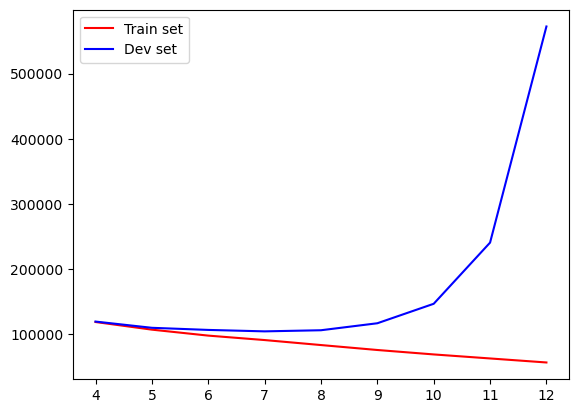

In [42]:
poly_deg = np.arange(4,13)
plt.plot(poly_deg, error_train, color = 'r', label = 'Train set')
plt.plot(poly_deg, error_cv, color = 'b', label = 'Dev set')

plt.legend()

In [4]:
# separate out features and target
features = df_clean.drop(columns=["Rented Bike Count", "Functioning Day","Date"] )
target = df_clean["Rented Bike Count"]  

# split data into train/test/validation

x_train, x_, y_train, y_ = train_test_split(features, target, test_size=0.4,
                                            random_state = 1)
# Split the subset above into two: one half for cross validation and the other for the test set
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

linear_model_daily = model_linear.ModelLinear(n_poly = 7, n_features = 6)
trained_model = linear_model_daily.train_model(
                    x_train = x_train,
                    y_train = y_train)

pred_train = trained_model.predict(x_train)
pred_cv = trained_model.predict(x_cv)

mean_absolute_error(y_cv, pred_cv)

178.53021954500207

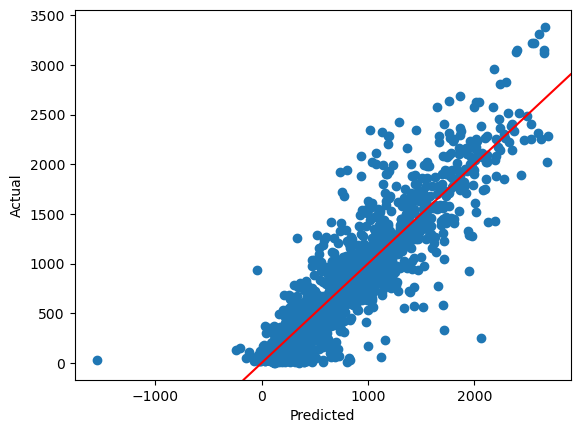

In [5]:
plt.scatter(pred_cv, y_cv)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.axline((0, 0), slope=1, color = 'r')

In [20]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import r_regression, f_regression

# Create and fit selector
selector = SelectKBest(r_regression, k=7)
selector.fit(features, target)
# Get columns to keep and create new dataframe with those only
cols_idxs = selector.get_support(indices=True)
features_df_new = features.iloc[:,cols_idxs]
features_df_new

,Hour,Temperature(°C),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Seasons
2017-12-01 00:00:00,0,-5.2,2.2,2000,-17.6,0.0,0
2017-12-01 01:00:00,1,-5.5,0.8,2000,-17.6,0.0,0
2017-12-01 02:00:00,2,-6.0,1.0,2000,-17.7,0.0,0
2017-12-01 03:00:00,3,-6.2,0.9,2000,-17.6,0.0,0
2017-12-01 04:00:00,4,-6.0,2.3,2000,-18.6,0.0,0
...,...,...,...,...,...,...,...
2018-11-30 19:00:00,19,4.2,2.6,1894,-10.3,0.0,3
2018-11-30 20:00:00,20,3.4,2.3,2000,-9.9,0.0,3
2018-11-30 21:00:00,21,2.6,0.3,1968,-9.9,0.0,3
2018-11-30 22:00:00,22,2.1,1.0,1859,-9.8,0.0,3


In [40]:
df_low_count = df_clean.loc[df_clean['Rented Bike Count'] < 30]
df_low_count


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
2017-12-03 06:00:00,03/12/2017,13,6,3.4,86,2.5,278,1.2,0.0,1.0,0.0,0,0,1
2017-12-03 07:00:00,03/12/2017,22,7,3.1,91,1.2,129,1.7,0.0,0.0,0.0,0,0,1
2017-12-10 05:00:00,10/12/2017,13,5,0.3,74,1.0,178,-3.7,0.0,0.0,0.7,0,0,1
2017-12-10 06:00:00,10/12/2017,9,6,-0.5,90,0.9,91,-1.9,0.0,2.5,2.7,0,0,1
2017-12-10 07:00:00,10/12/2017,20,7,-0.4,92,1.1,121,-1.5,0.0,0.0,4.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-08 20:00:00,08/11/2018,12,20,13.9,97,2.5,594,13.4,0.0,0.0,0.0,3,0,1
2018-11-08 21:00:00,08/11/2018,21,21,14.0,96,4.1,292,13.3,0.0,18.0,0.0,3,0,1
2018-11-08 22:00:00,08/11/2018,14,22,12.4,96,2.7,545,11.7,0.0,0.0,0.0,3,0,1
2018-11-08 23:00:00,08/11/2018,26,23,11.5,96,3.0,691,10.8,0.0,0.0,0.0,3,0,1


Text(0, 0.5, 'Rented Bike Count')

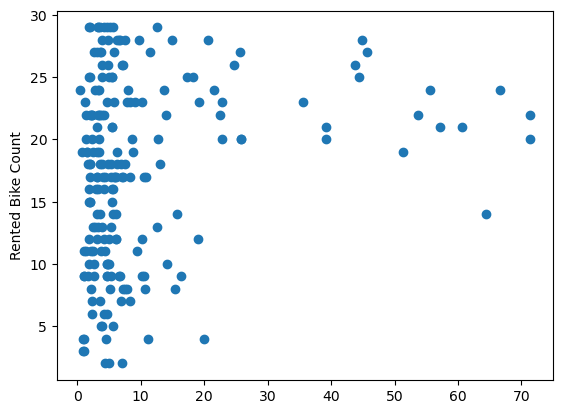

In [48]:
plt.scatter( (1/df_low_count['Humidity(%)']) * df_low_count['Visibility (10m)'], 
            df_low_count['Rented Bike Count'])
plt.ylabel('Rented Bike Count')
# plt.xlim(0,20)

Text(0, 0.5, 'Rented Bike Count')

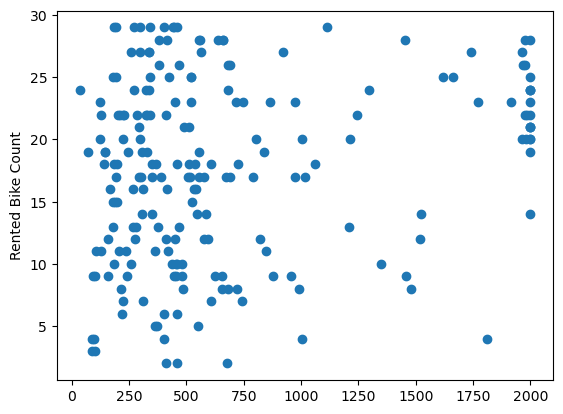

In [42]:
plt.scatter(df_low_count['Visibility (10m)'], df_low_count['Rented Bike Count'])
plt.ylabel('Rented Bike Count')

In [12]:
1/1e-3

1000.0

<Axes: >

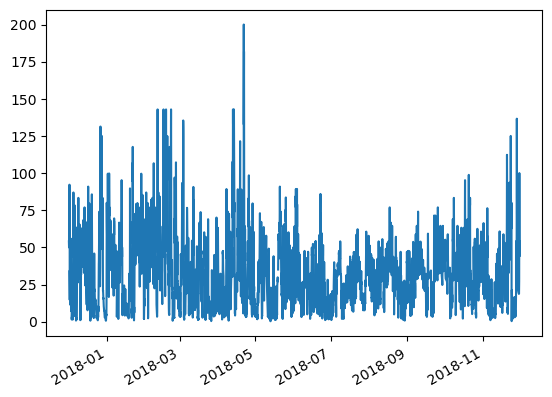

In [8]:
df_clean.foggy.plot()